# SNAPflow v2: Burst-Based InSAR Notebook

This notebook documents a burst-native Sentinel-1 interferometric workflow built on `phidown` for burst discovery and on SNAP for downstream processing. The notebook is written as a compact technical report so it can be executed operationally while still reading clearly as a university-style processing note.

The sequence is intentionally explicit: search and validate candidate bursts, resolve a compatible master-slave pair, retrieve burst archives on demand, and process the extracted `.SAFE` products through orbit correction, co-registration, interferogram generation, topographic phase removal, and terrain correction.

From an InSAR perspective, the central complex observable is the interferogram

\[ I_{\mathrm{ifg}} = M \cdot S^{*} \]

where \(M\) is the master acquisition and \(S^{*}\) is the complex conjugate of the slave acquisition. Its phase contains deformation, topographic, orbital, and atmospheric contributions. The downstream SNAP steps progressively reduce the non-target terms and map the result into a terrain-corrected grid suited for interpretation.

The final section emphasizes interpretability. It surfaces concise tables and restrained figures that follow an IEEE-inspired report style: moderate DPI, serif typography, limited color, and captions focused on measurement meaning rather than decoration.


In [1]:
from pathlib import Path
import copy
import json
import os

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

from phidown import plot_product_footprints, run_burst_workflow
from phidown.downloader import download_burst_on_demand, get_token

from sarpyx.snapflow.burst_utils import extract_burst_archive, select_burst_pair
from sarpyx.snapflow.engine import GPT

pd.set_option("display.max_columns", None)

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
REPO_ROOT = NOTEBOOK_DIR.parent
load_dotenv(REPO_ROOT / ".env")
DATA_DIR = REPO_ROOT / "data"
BURST_DIR = DATA_DIR / "bursts"
OUTPUT_DIR = DATA_DIR / "output" / "snapflow_v2"
STATS_DIR = OUTPUT_DIR / "burst_search"
PROCESS_DIR = OUTPUT_DIR / "processing"
SNAP_USERDIR = Path(os.getenv("SNAP_USERDIR", REPO_ROOT / ".snap"))
SNAP_TMPDIR = Path(os.getenv("SNAP_TMPDIR", REPO_ROOT / ".tmp" / "snapflow_v2"))
DEFAULT_GPT_PATH = Path.home() / "esa-snap" / "bin" / "gpt"
if os.getenv("GPT_PATH"):
    GPT_PATH = Path(os.getenv("GPT_PATH"))
elif DEFAULT_GPT_PATH.exists():
    GPT_PATH = DEFAULT_GPT_PATH
else:
    GPT_PATH = Path("/usr/local/snap/bin/gpt")


def first_env(*names: str) -> str | None:
    for name in names:
        value = os.getenv(name)
        if value:
            return value
    return None


def display_path(path: str | Path) -> str:
    path = Path(path)
    try:
        return path.relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return path.name


CDSE_USERNAME = first_env("CDSE_USERNAME", "CDSE_USR")
CDSE_PASSWORD = first_env("CDSE_PASSWORD", "CDSE_PSW")

for path in (DATA_DIR, BURST_DIR, OUTPUT_DIR, STATS_DIR, PROCESS_DIR, SNAP_USERDIR, SNAP_TMPDIR):
    path.mkdir(parents=True, exist_ok=True)

os.environ["TMPDIR"] = SNAP_TMPDIR.as_posix()
java_tmp_opt = f"-Djava.io.tmpdir={SNAP_TMPDIR.as_posix()}"
existing_java_tool_options = os.getenv("JAVA_TOOL_OPTIONS", "").strip()
if java_tmp_opt not in existing_java_tool_options.split():
    merged = f"{existing_java_tool_options} {java_tmp_opt}".strip()
    os.environ["JAVA_TOOL_OPTIONS"] = merged

print(json.dumps({
    "workspace": REPO_ROOT.name,
    "burst_dir": display_path(BURST_DIR),
    "output_dir": display_path(OUTPUT_DIR),
    "stats_dir": display_path(STATS_DIR),
    "process_dir": display_path(PROCESS_DIR),
    "gpt_binary": GPT_PATH.name,
    "gpt_exists": GPT_PATH.exists(),
    "snap_userdir": display_path(SNAP_USERDIR),
    "snap_tmpdir": display_path(SNAP_TMPDIR),
    "has_cdse_username": bool(CDSE_USERNAME),
    "has_cdse_password": bool(CDSE_PASSWORD),
}, indent=2))


{
  "workspace": "srp",
  "burst_dir": "data/bursts",
  "output_dir": "data/output/snapflow_v2",
  "stats_dir": "data/output/snapflow_v2/burst_search",
  "process_dir": "data/output/snapflow_v2/processing",
  "gpt_binary": "gpt",
  "gpt_exists": true,
  "snap_userdir": ".snap",
  "snap_tmpdir": ".tmp/snapflow_v2",
  "has_cdse_username": true,
  "has_cdse_password": true
}


## Burst Search Configuration

Set the AOI and time window first. Burst data is available from **2024-08-02** onward.

Leave `MASTER_BURST_UUID` and `SLAVE_BURST_UUID` as `None` to auto-select the best compatible pair from the search results. In practice, this allows the notebook to search broadly first and then restrict the analysis to a geometrically compatible burst pair with sufficient overlap and a stable orbital configuration.


In [2]:
AOI_WKT = "POLYGON((12.4 41.8, 12.6 41.8, 12.6 42.0, 12.4 42.0, 12.4 41.8))"

MASTER_BURST_UUID = None
SLAVE_BURST_UUID = None

SEARCH_CONFIG = {
    "search": {
        "aoi_wkt": AOI_WKT,
        "start_date": "2025-01-01T00:00:00",
        "end_date": "2025-03-01T00:00:00",
        "polarisation": "VV",
        "orbit_direction": None,
        "relative_orbit": None,
        "platforms": ["all"],
        "swath_identifier": None,
        "burst_id": None,
        "max_results": 300,
    },
    "output_statistics": STATS_DIR.as_posix(),
    "save_results_csv": True,
}

SEARCH_CONFIG_DISPLAY = copy.deepcopy(SEARCH_CONFIG)
SEARCH_CONFIG_DISPLAY["output_statistics"] = display_path(STATS_DIR)

print(json.dumps(SEARCH_CONFIG_DISPLAY, indent=2))


{
  "search": {
    "aoi_wkt": "POLYGON((12.4 41.8, 12.6 41.8, 12.6 42.0, 12.4 42.0, 12.4 41.8))",
    "start_date": "2025-01-01T00:00:00",
    "end_date": "2025-03-01T00:00:00",
    "polarisation": "VV",
    "orbit_direction": null,
    "relative_orbit": null,
    "platforms": [
      "all"
    ],
    "swath_identifier": null,
    "burst_id": null,
    "max_results": 300
  },
  "output_statistics": "data/output/snapflow_v2/burst_search",
  "save_results_csv": true
}


## Run `phidown` Burst Workflow

This mirrors the upstream burst validation notebook: search, orbit recommendation, temporal statistics, validation, and footprint QA all happen before any burst download or SNAP processing.

This stage acts as a verification gate. Before any SNAP runtime is spent, it confirms that the AOI is covered, that the candidate bursts are temporally sensible, and that the selected products are valid for a consistent interferometric pair.


In [3]:
result = run_burst_workflow(SEARCH_CONFIG)

df = result["df"]
stats = result["stats"]
validation = result["validation"]
debug = result["debug"]
orbit = result.get("orbit") or {}
paths = result.get("paths") or {}

print("Rows:", len(df))
print("Orbit:", orbit)
print("Validation:", validation)
print("Output files:", {k: display_path(v) for k, v in paths.items()})


INFO:phidown.search:Analyzing ASCENDING orbits...


INFO:phidown.search:Analyzing DESCENDING orbits...


INFO:phidown.search:Analyzing ASCENDING orbits...


INFO:phidown.search:Analyzing DESCENDING orbits...


Rows: 8
Orbit: {'analysis': {'ascending': {'orbits': {117: {'avg_coverage': 100.0, 'max_coverage': 100.0, 'count': 4}}, 'best_orbit': 117, 'max_coverage': 100.0}, 'descending': {'orbits': {22: {'avg_coverage': 82.79, 'max_coverage': 97.62, 'count': 10}, 95: {'avg_coverage': 63.63, 'max_coverage': 100.0, 'count': 10}}, 'best_orbit': 22, 'max_coverage': 82.79}, 'recommended': {'orbit_direction': 'ASCENDING', 'relative_orbit': 117, 'expected_coverage': 100.0}}, 'orbit_direction': 'ASCENDING', 'relative_orbit': 117}
Validation: {'ok': True, 'errors': [], 'warnings': []}
Output files: {'search_results_csv': 'data/output/snapflow_v2/burst_search/search_results.csv', 'temporal_statistics_json': 'data/output/snapflow_v2/burst_search/temporal_statistics.json', 'validation_report_json': 'data/output/snapflow_v2/burst_search/validation_report.json', 'debug_summary_json': 'data/output/snapflow_v2/burst_search/debug_summary.json', 'coverage_plot_png': 'data/output/snapflow_v2/burst_search/coverage_

,@odata.mediaContentType,Id,Name,ContentType,S3Path,ContentDate,Footprint,GeoFootprint,ParentProductId,ParentProductName,ByteOffset,BurstId,AbsoluteBurstId,AzimuthTime,AzimuthAnxTime,ParentProductType,SwathIdentifier,RelativeOrbitNumber,OrbitDirection,PlatformSerialIdentifier,PolarisationChannels,OperationalMode,DatatakeID,Lines,LinesPerBurst,SamplesPerBurst,BeginningDateTime,EndingDateTime,coverage,subswath_priority
0,application/octet-stream,8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03,S1A-SLC-20250217T170613-249406-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:13.727886Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,640810107,249406,124446891,2025-02-17T17:06:12.711058Z,678.918613,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,6048,1512,26484,2025-02-17T17:06:13.727886Z,2025-02-17T17:06:14.769476Z,59.83,1
1,application/octet-stream,2404a519-5e05-4dcc-95e5-b3e4e8a79127,S1A-SLC-20250205T170614-249406-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:14.317745Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,800997435,249406,124071003,2025-02-05T17:06:13.305030Z,678.925139,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,466741,7560,1512,26484,2025-02-05T17:06:14.317745Z,2025-02-05T17:06:15.359335Z,59.83,1
2,application/octet-stream,ed949647-6573-484a-a49c-913d80e51117,S1A-SLC-20250124T170614-249406-IW2-VV-464973,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/24/S...,"{'Start': '2025-01-24T17:06:14.811016Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",21332892-321f-4954-b01e-6247318c0c60,S1A_IW_SLC__1SDV_20250124T170600_20250124T1706...,640810107,249406,123695116,2025-01-24T17:06:13.792121Z,678.918260,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,464973,6048,1512,26484,2025-01-24T17:06:14.811016Z,2025-01-24T17:06:15.852606Z,59.83,1
3,application/octet-stream,cedb52f3-9e96-49b9-a6a3-d7b195c6918e,S1A-SLC-20250112T170615-249406-IW2-VV-463192,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/12/S...,"{'Start': '2025-01-12T17:06:15.657009Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",6b19852e-76d9-4d8f-872d-1e454a903b10,S1A_IW_SLC__1SDV_20250112T170601_20250112T1706...,640810107,249406,123319229,2025-01-12T17:06:14.638116Z,678.920017,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,463192,6048,1512,26484,2025-01-12T17:06:15.657009Z,2025-01-12T17:06:16.698599Z,59.83,1
4,application/octet-stream,ead48acc-c11b-418b-9aac-a550d8eee23f,S1A-SLC-20250217T170610-249405-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:10.969609Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,480634875,249405,124446890,2025-02-17T17:06:09.958669Z,676.166224,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,4536,1512,26484,2025-02-17T17:06:10.969609Z,2025-02-17T17:06:12.011199Z,51.88,1
5,application/octet-stream,dee9e6c1-b963-49a6-82ff-fed6581814b4,S1A-SLC-20250205T170611-249405-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:11.559468Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,640822203,249405,124071002,2025-02-05T17:06:10.552640Z,676.172749,IW_SLC__1S,IW

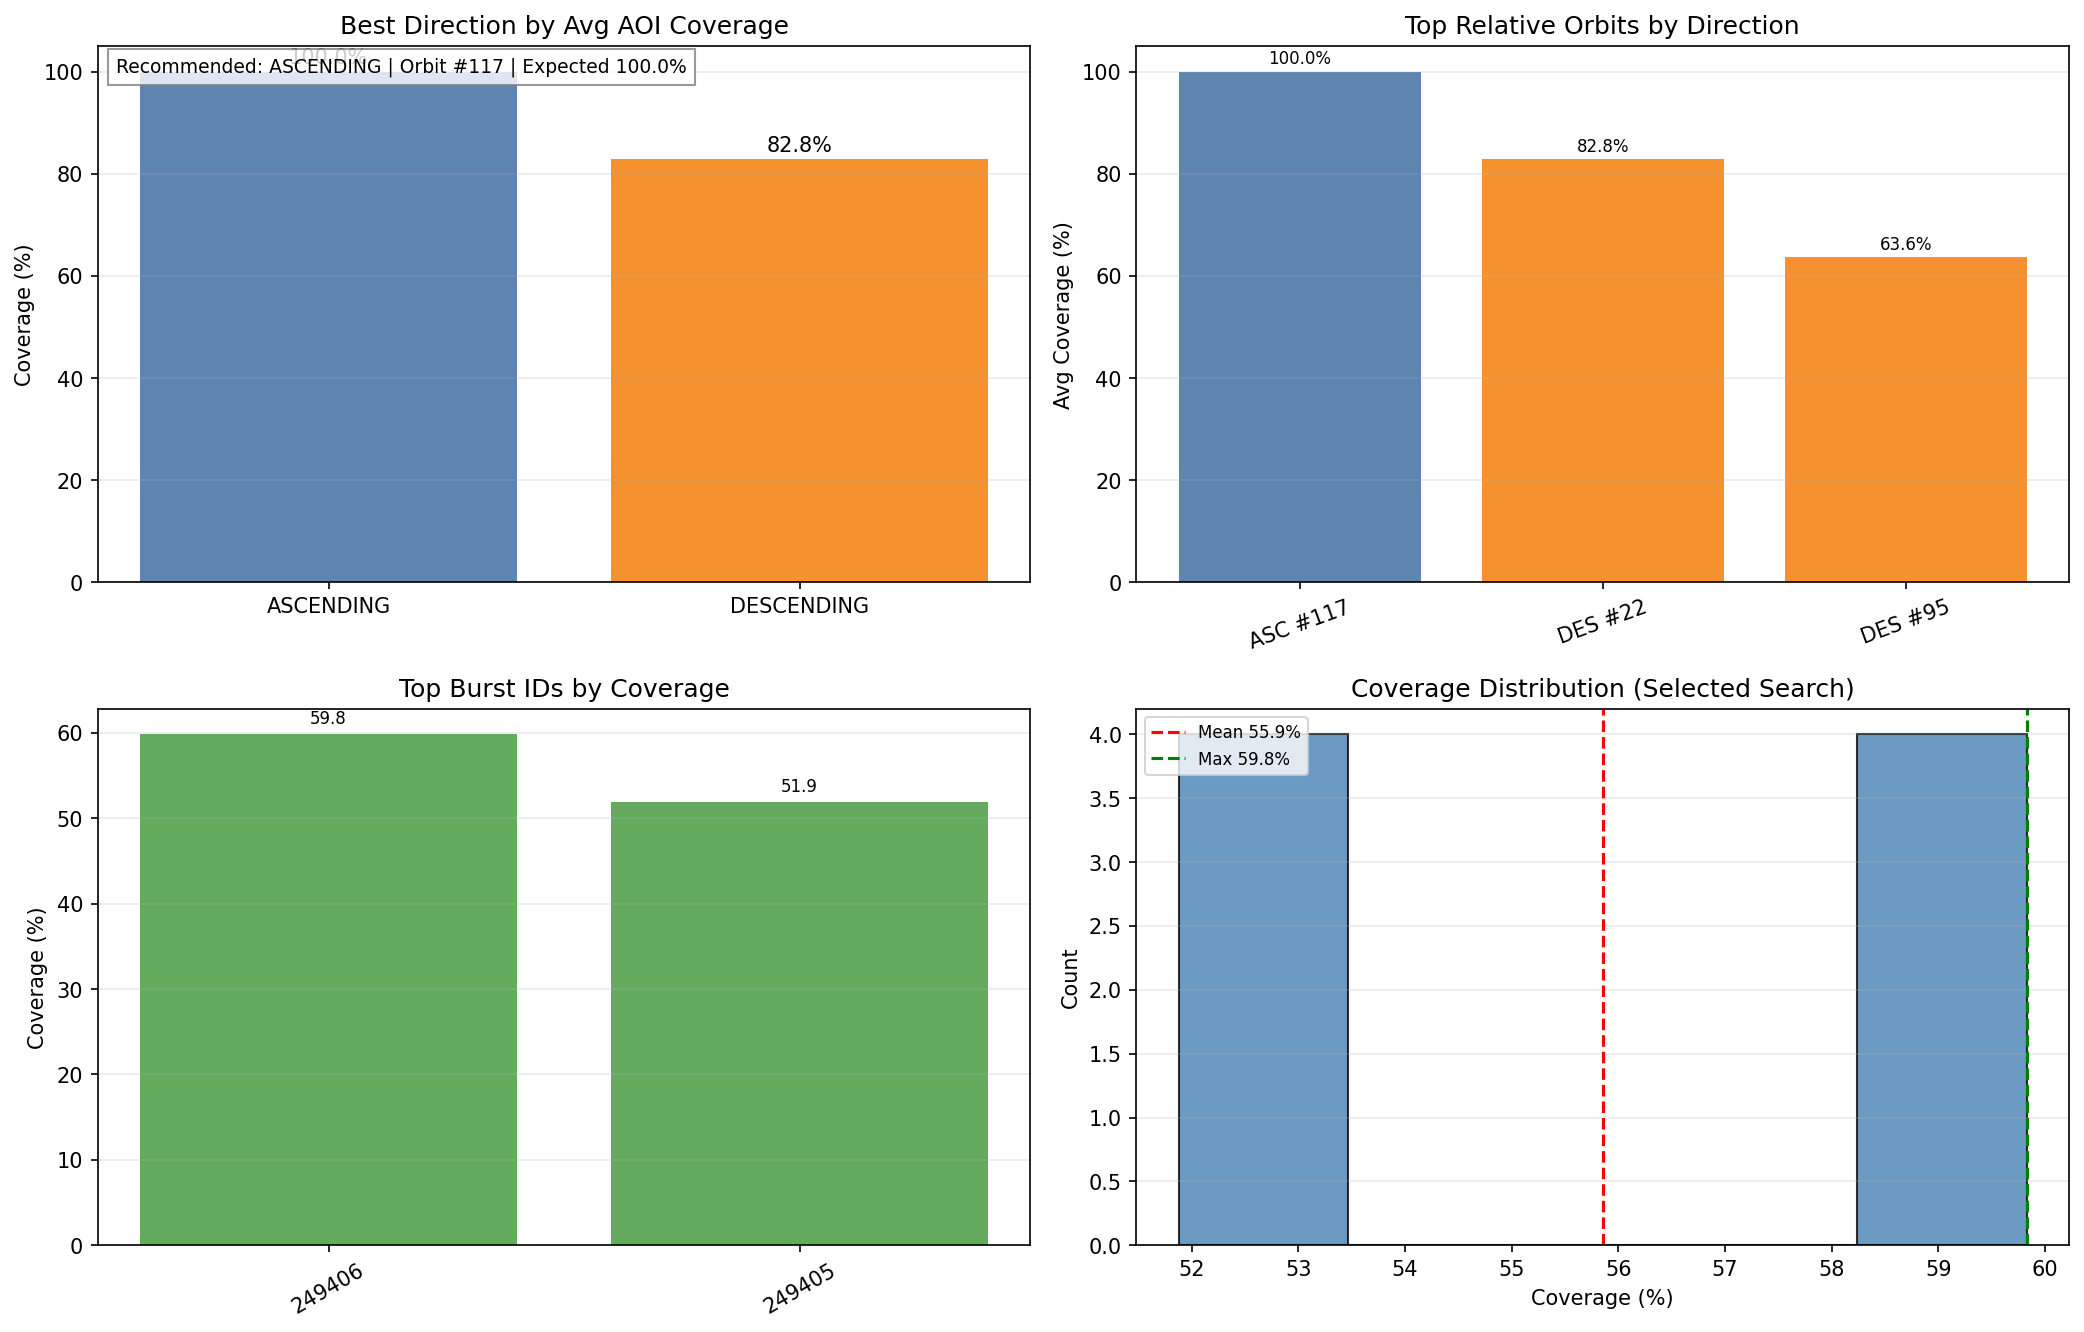

In [4]:
assert validation["ok"], f"Validation failed: {validation['errors']}"
display(df.head(10))

coverage_plot = paths.get("coverage_plot_png")
if coverage_plot:
    display(Image(filename=Path(coverage_plot).as_posix()))

df_map = df.copy()
if "coverage" in df_map.columns:
    df_map["coverage"] = pd.to_numeric(df_map["coverage"], errors="coerce")
    df_map = df_map[df_map["coverage"] > 0].copy()

burst_map = plot_product_footprints(
    df=df_map,
    aoi_wkt=AOI_WKT,
    top_n=len(df_map) if len(df_map) else 1,
    name_col="ParentProductName",
    id_col="Id",
    group_by="product",
    add_layer_control=True,
)
burst_map


## Resolve the Burst Pair

When no manual UUIDs are provided, `select_burst_pair(...)` groups results by `BurstId`, `SwathIdentifier`, `RelativeOrbitNumber`, `OrbitDirection`, and `PolarisationChannels`, then ranks by max coverage and recency. The most recent acquisition becomes the master.

This matters because burst-level InSAR is only meaningful when both acquisitions share the same acquisition geometry. The pairing logic therefore prioritizes compatibility first and recency second.


In [5]:
selection = select_burst_pair(
    df,
    master_id=MASTER_BURST_UUID,
    slave_id=SLAVE_BURST_UUID,
)

MASTER_BURST_ID = selection.master.id
SLAVE_BURST_ID = selection.slave.id

display(pd.DataFrame([
    {
        "role": "master",
        "id": selection.master.id,
        "burst_id": selection.master.burst_id,
        "swath": selection.master.swath_identifier,
        "relative_orbit": selection.master.relative_orbit_number,
        "orbit_direction": selection.master.orbit_direction,
        "polarisation": selection.master.polarisation_channels,
        "parent_product": selection.master.parent_product_name,
        "content_start": selection.master.content_start.isoformat(),
        "coverage": selection.master.coverage,
    },
    {
        "role": "slave",
        "id": selection.slave.id,
        "burst_id": selection.slave.burst_id,
        "swath": selection.slave.swath_identifier,
        "relative_orbit": selection.slave.relative_orbit_number,
        "orbit_direction": selection.slave.orbit_direction,
        "polarisation": selection.slave.polarisation_channels,
        "parent_product": selection.slave.parent_product_name,
        "content_start": selection.slave.content_start.isoformat(),
        "coverage": selection.slave.coverage,
    },
]))


,role,id,burst_id,swath,relative_orbit,orbit_direction,polarisation,parent_product,content_start,coverage
0,master,8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03,249406,IW2,117,ASCENDING,VV,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,2025-02-17T17:06:13.727886+00:00,59.83
1,slave,2404a519-5e05-4dcc-95e5-b3e4e8a79127,249406,IW2,117,ASCENDING,VV,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,2025-02-05T17:06:14.317745+00:00,59.83


## Download and Extract Bursts

Burst products are requested through the CDSE burst processing endpoint, not via `.s5cfg` / S3. This cell reuses a single archive already present in the role-specific folder, otherwise it requests the burst on demand and then extracts it to one `.SAFE` root.

The extraction step is kept explicit because the downstream SNAP operators expect a well-formed `.SAFE` product tree. Failing early here is preferable to discovering a malformed input later in the processing chain.


In [6]:
ACCESS_TOKEN = None


def ensure_burst_archive(burst_uuid: str, role: str) -> Path:
    global ACCESS_TOKEN
    role_dir = BURST_DIR / role / burst_uuid
    role_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(role_dir.glob("*.zip"))
    if len(existing) == 1:
        return existing[0]
    if len(existing) > 1:
        raise RuntimeError(f"Expected at most one cached archive in {role_dir}, found {len(existing)}")

    if not CDSE_USERNAME or not CDSE_PASSWORD:
        raise ValueError("Set CDSE_USERNAME/CDSE_PASSWORD or CDSE_USR/CDSE_PSW before downloading bursts")

    if ACCESS_TOKEN is None:
        ACCESS_TOKEN = get_token(username=CDSE_USERNAME, password=CDSE_PASSWORD)

    download_burst_on_demand(burst_id=burst_uuid, token=ACCESS_TOKEN, output_dir=role_dir)

    refreshed = sorted(role_dir.glob("*.zip"))
    if len(refreshed) != 1:
        raise RuntimeError(
            f"Expected exactly one burst archive after download in {role_dir}, found {len(refreshed)}"
        )
    return refreshed[0]


MASTER_ARCHIVE = ensure_burst_archive(MASTER_BURST_ID, "master")
SLAVE_ARCHIVE = ensure_burst_archive(SLAVE_BURST_ID, "slave")

MASTER_PRODUCT = extract_burst_archive(MASTER_ARCHIVE, BURST_DIR / "extracted" / "master" / MASTER_BURST_ID)
SLAVE_PRODUCT = extract_burst_archive(SLAVE_ARCHIVE, BURST_DIR / "extracted" / "slave" / SLAVE_BURST_ID)

print(json.dumps({
    "master_archive": MASTER_ARCHIVE.name,
    "slave_archive": SLAVE_ARCHIVE.name,
    "master_product": display_path(MASTER_PRODUCT),
    "slave_product": display_path(SLAVE_PRODUCT),
}, indent=2))


{
  "master_archive": "S1A_SLC_20250217T170613_249406_IW2_VV_468546.zip",
  "slave_archive": "S1A_SLC_20250205T170614_249406_IW2_VV_466741.zip",
  "master_product": "data/bursts/extracted/master/8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03/S1A_SLC_20250217T170613_249406_IW2_VV_468546/S1A_SLC_20250217T170613_249406_IW2_VV_468546.SAFE",
  "slave_product": "data/bursts/extracted/slave/2404a519-5e05-4dcc-95e5-b3e4e8a79127/S1A_SLC_20250205T170614_249406_IW2_VV_466741/S1A_SLC_20250205T170614_249406_IW2_VV_466741.SAFE"
}


## Burst-Native Processing Configuration

These settings keep the burst workflow simple and explicit:
- `Apply-Orbit-File` runs on each extracted burst product independently
- `TOPSAR-Split` is skipped because each input is already a single burst product
- `use_esd=False` is passed to `topsar_coregistration(...)`
- `subset` is optional and disabled by default because the burst is already spatially focused

At burst level, the design goal is to avoid unnecessary operators. The products are already spatially constrained, so the notebook keeps only the steps required to improve orbital accuracy, align master and slave geometry, remove topographic phase, and project the result into a map geometry suitable for inspection.


In [7]:
DEM_NAME = "Copernicus 30m Global DEM"
PIXEL_SPACING_M = 14.0
SUBSET_REGION = None

if not GPT_PATH.exists():
    print(f"SNAP gpt not found at {GPT_PATH}. Update GPT_PATH before running processing cells.")


## Run SNAPFlow Processing

The output sequence is:
- orbit-correct master burst
- orbit-correct slave burst
- pairwise coregistration with `use_esd=False`
- deburst
- interferogram
- topo phase removal
- optional subset
- terrain correction

Conceptually, the processing chain applies the standard burst InSAR logic:

1. Orbit refinement reduces geometric inconsistency between the acquisitions.
2. Co-registration aligns master and slave pixels so that each complex sample refers to the same ground target.
3. Interferogram formation computes \(M \cdot S^{*}\), from which wrapped phase and coherence can be derived.
4. Topographic phase removal subtracts the DEM-predicted terrain contribution, leaving a cleaner residual phase.
5. Terrain correction maps the result into a geocoded grid with controlled pixel spacing.

The coherence quantity reported later is the normalized magnitude of local complex correlation, commonly written as

\[ \gamma = \frac{|\langle M S^{*} \rangle|}{\sqrt{\langle |M|^2 \rangle \langle |S|^2 \rangle}} \]

where values closer to 1 indicate stronger local similarity between the two acquisitions.


In [8]:
def build_gpt(product: str | Path, outdir: str | Path) -> GPT:
    return GPT(
        product=product,
        outdir=outdir,
        format="BEAM-DIMAP",
        gpt_path=GPT_PATH.as_posix(),
        snap_userdir=SNAP_USERDIR,
    )


def ensure_orbit_product(product: Path, role: str) -> Path:
    role_dir = PROCESS_DIR / role
    target = role_dir / f"{product.stem}_ORB.dim"
    if target.exists():
        return target

    gpt = build_gpt(product, role_dir)
    orbit_path = gpt.apply_orbit_file(output_name=f"{product.stem}_ORB")
    if orbit_path is None:
        raise RuntimeError(gpt.last_error_summary())
    return Path(orbit_path)


prepared_master = ensure_orbit_product(MASTER_PRODUCT, "master")
prepared_slave = ensure_orbit_product(SLAVE_PRODUCT, "slave")

pair_outdir = PROCESS_DIR / "pair"
pair_gpt = build_gpt(prepared_master, pair_outdir)

coreg_target = pair_outdir / "pair_coreg.dim"
if coreg_target.exists():
    pair_gpt.prod_path = coreg_target
    coreg_path = coreg_target.as_posix()
else:
    coreg_path = pair_gpt.topsar_coregistration(
        master_product=prepared_master,
        slave_product=prepared_slave,
        use_esd=False,
        dem_name=DEM_NAME,
        output_name="pair_coreg",
        keep_graph=True,
    )
    if coreg_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

deburst_target = pair_outdir / "pair_coreg_deb.dim"
if deburst_target.exists():
    pair_gpt.prod_path = deburst_target
    deburst_path = deburst_target.as_posix()
else:
    deburst_path = pair_gpt.deburst(output_name="pair_coreg_deb")
    if deburst_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

ifg_target = pair_outdir / "pair_ifg.dim"
if ifg_target.exists():
    pair_gpt.prod_path = ifg_target
    ifg_path = ifg_target.as_posix()
else:
    ifg_path = pair_gpt.interferogram(
        subtract_flat_earth_phase=True,
        include_coherence=True,
        output_name="pair_ifg",
    )
    if ifg_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

topo_target = pair_outdir / "pair_ifg_topo.dim"
if topo_target.exists():
    pair_gpt.prod_path = topo_target
    topo_path = topo_target.as_posix()
else:
    topo_path = pair_gpt.topo_phase_removal(
        dem_name=DEM_NAME,
        output_name="pair_ifg_topo",
    )
    if topo_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

subset_path = None
terrain_source = Path(topo_path)
if SUBSET_REGION:
    subset_target = pair_outdir / "pair_ifg_subset.dim"
    if subset_target.exists():
        pair_gpt.prod_path = subset_target
        subset_path = subset_target.as_posix()
    else:
        subset_path = pair_gpt.subset(
            region=SUBSET_REGION,
            copy_metadata=True,
            output_name="pair_ifg_subset",
        )
        if subset_path is None:
            raise RuntimeError(pair_gpt.last_error_summary())
    terrain_source = Path(subset_path)

terrain_gpt = build_gpt(terrain_source, pair_outdir)
terrain_target = pair_outdir / "pair_ifg_tc.dim"
if terrain_target.exists():
    terrain_path = terrain_target.as_posix()
else:
    terrain_path = terrain_gpt.terrain_correction(
        dem_name=DEM_NAME,
        pixel_spacing_in_meter=PIXEL_SPACING_M,
        save_selected_source_band=True,
        save_local_incidence_angle=True,
        output_name="pair_ifg_tc",
    )
    if terrain_path is None:
        raise RuntimeError(terrain_gpt.last_error_summary())

PROCESS_OUTPUTS = {
    "prepared_master": prepared_master.as_posix(),
    "prepared_slave": prepared_slave.as_posix(),
    "coregistration": coreg_path,
    "deburst": deburst_path,
    "interferogram": ifg_path,
    "topo_phase_removal": topo_path,
    "subset": subset_path,
    "terrain_correction": terrain_path,
}

PROCESS_OUTPUTS_DISPLAY = {
    key: (display_path(value) if value else None)
    for key, value in PROCESS_OUTPUTS.items()
}

print(json.dumps(PROCESS_OUTPUTS_DISPLAY, indent=2))


{
  "prepared_master": "data/output/snapflow_v2/processing/master/S1A_SLC_20250217T170613_249406_IW2_VV_468546_ORB.dim",
  "prepared_slave": "data/output/snapflow_v2/processing/slave/S1A_SLC_20250205T170614_249406_IW2_VV_466741_ORB.dim",
  "coregistration": "data/output/snapflow_v2/processing/pair/pair_coreg.dim",
  "deburst": "data/output/snapflow_v2/processing/pair/pair_coreg_deb.dim",
  "interferogram": "data/output/snapflow_v2/processing/pair/pair_ifg.dim",
  "topo_phase_removal": "data/output/snapflow_v2/processing/pair/pair_ifg_topo.dim",
  "subset": null,
  "terrain_correction": "data/output/snapflow_v2/processing/pair/pair_ifg_tc.dim"
}


## Preview Outputs

This section keeps operational details concise while surfacing the most relevant diagnostics for interpretation.

Product inventory, descriptive statistics, and quicklook graphics are separated into focused cells so each artifact can be reviewed independently on GitHub or in Jupyter. The figures use a restrained professional university style with moderate DPI, serif fonts, and limited, measurement-oriented color choices.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

IEEE_RC = {
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#4b5563",
    "axes.labelcolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#d1d5db",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.55,
    "legend.frameon": True,
    "legend.fontsize": 9,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
}

sns.set_theme(context="paper", style="whitegrid", rc=IEEE_RC)

IEEE_COLORS = {
    "navy": "#1f3c73",
    "blue": "#2b6cb0",
    "teal": "#2c7a7b",
    "gold": "#b7791f",
    "crimson": "#b83280",
    "gray": "#6b7280",
}

ENVI_DTYPE_MAP = {
    "1": np.uint8,
    "2": np.int16,
    "3": np.int32,
    "4": np.float32,
    "5": np.float64,
    "6": np.complex64,
    "9": np.complex128,
    "12": np.uint16,
    "13": np.uint32,
    "14": np.int64,
    "15": np.uint64,
}


def data_dir_for(product_path: str | Path) -> Path:
    return Path(product_path).with_suffix(".data")


def parse_envi_header(hdr_path: str | Path) -> dict[str, str]:
    values: dict[str, str] = {}
    for line in Path(hdr_path).read_text().splitlines():
        if " = " not in line:
            continue
        key, value = line.split(" = ", 1)
        values[key.strip().lower()] = value.strip().strip("{}")
    required = ["samples", "lines", "bands", "data type", "byte order"]
    missing = [key for key in required if key not in values]
    if missing:
        raise ValueError(f"Missing ENVI metadata in {hdr_path}: {missing}")
    return values


def read_envi_quicklook(img_path: str | Path, max_side: int = 1200) -> np.ndarray:
    img_path = Path(img_path)
    header = parse_envi_header(img_path.with_suffix(".hdr"))
    samples = int(header["samples"])
    lines = int(header["lines"])
    bands = int(header["bands"])
    if bands != 1:
        raise ValueError(f"Preview helper expects single-band rasters, got {bands} for {img_path}")
    dtype = np.dtype(ENVI_DTYPE_MAP[header["data type"]])
    if header["byte order"] == "1":
        dtype = dtype.newbyteorder(">")
    array = np.memmap(img_path, dtype=dtype, mode="r", shape=(lines, samples))
    step = max(1, int(np.ceil(max(lines, samples) / max_side)))
    return np.asarray(array[::step, ::step], dtype=np.float32)


def first_matching_band(product_path: str | Path, *needles: str) -> Path | None:
    data_dir = data_dir_for(product_path)
    if not data_dir.exists():
        return None
    candidates = sorted(data_dir.glob("*.img"))
    lowered = [(path, path.name.lower()) for path in candidates]
    for needle in needles:
        target = needle.lower()
        for path, lower_name in lowered:
            if target in lower_name:
                return path
    return None


def wrapped_phase(i_band: str | Path, q_band: str | Path, max_side: int = 1200) -> np.ndarray:
    i_data = read_envi_quicklook(i_band, max_side=max_side)
    q_data = read_envi_quicklook(q_band, max_side=max_side)
    return np.arctan2(q_data, i_data)


def robust_limits(array: np.ndarray, low: float = 2.0, high: float = 98.0) -> tuple[float, float]:
    valid = array[np.isfinite(array)]
    if valid.size == 0:
        return (0.0, 1.0)
    lo, hi = np.nanpercentile(valid, [low, high])
    if float(lo) == float(hi):
        hi = lo + 1.0
    return float(lo), float(hi)


def preview_band_list(product_path: str | Path, limit: int = 6) -> str:
    bands = sorted(path.stem for path in data_dir_for(product_path).glob("*.img"))
    if not bands:
        return ""
    if len(bands) <= limit:
        return ", ".join(bands)
    return ", ".join(bands[:limit]) + f", ... (+{len(bands) - limit} more)"


def mark_empty(axis: plt.Axes, message: str) -> None:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.grid(False)
    axis.set_facecolor("#f8fafc")
    axis.text(
        0.5,
        0.5,
        message,
        ha="center",
        va="center",
        fontsize=10,
        color="#374151",
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "#cbd5e1"},
    )


def apply_map_format(axis: plt.Axes) -> None:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#6b7280")


summary_rows = []
for label, product_path in PROCESS_OUTPUTS.items():
    if not product_path:
        continue
    product = Path(product_path)
    summary_rows.append({
        "stage": label,
        "product": product.name,
        "exists": product.exists(),
        "band_preview": preview_band_list(product),
    })

summary_df = pd.DataFrame(summary_rows)

terrain_product = Path(PROCESS_OUTPUTS["terrain_correction"])
topo_product = Path(PROCESS_OUTPUTS["topo_phase_removal"])
ifg_product = Path(PROCESS_OUTPUTS["interferogram"])

phase_product = terrain_product if terrain_product.exists() else topo_product
phase_i = first_matching_band(phase_product, "i_ifg_")
phase_q = first_matching_band(phase_product, "q_ifg_")
coherence_band = (
    first_matching_band(terrain_product, "coh_")
    or first_matching_band(topo_product, "coh_")
    or first_matching_band(ifg_product, "coh_")
)
incidence_band = first_matching_band(terrain_product, "localincidenceangle")
elevation_band = first_matching_band(terrain_product, "elevation")
support_band = incidence_band or elevation_band

coherence_data = read_envi_quicklook(coherence_band) if coherence_band else None
coherence_stats_rows = []
if coherence_data is not None:
    coherence_valid = coherence_data[np.isfinite(coherence_data)].ravel()
    coherence_stats_rows = [
        {"metric": "pixel_count", "value": int(coherence_valid.size)},
        {"metric": "mean", "value": float(np.nanmean(coherence_valid))},
        {"metric": "median", "value": float(np.nanmedian(coherence_valid))},
        {"metric": "std", "value": float(np.nanstd(coherence_valid))},
        {"metric": "p10", "value": float(np.nanpercentile(coherence_valid, 10))},
        {"metric": "p90", "value": float(np.nanpercentile(coherence_valid, 90))},
    ]

support_data = read_envi_quicklook(support_band) if support_band else None
support_stats_rows = []
if support_data is not None:
    support_valid = support_data[np.isfinite(support_data)].ravel()
    support_stats_rows = [
        {"metric": "band", "value": support_band.stem},
        {"metric": "pixel_count", "value": int(support_valid.size)},
        {"metric": "mean", "value": float(np.nanmean(support_valid))},
        {"metric": "median", "value": float(np.nanmedian(support_valid))},
        {"metric": "min", "value": float(np.nanmin(support_valid))},
        {"metric": "max", "value": float(np.nanmax(support_valid))},
    ]

coherence_stats_df = pd.DataFrame(coherence_stats_rows)
support_stats_df = pd.DataFrame(support_stats_rows)


### Output Summary

The summary table below verifies which processing stages produced valid outputs and lists the principal raster bands exposed by each product. This is the fastest way to confirm that the SNAP chain completed consistently and that the expected interferometric and terrain-derived bands are present before reading any figure.


In [10]:
display(summary_df)


,stage,product,exists,band_preview
0,prepared_master,S1A_SLC_20250217T170613_249406_IW2_VV_468546_O...,True,"i_IW2_VV, q_IW2_VV"
1,prepared_slave,S1A_SLC_20250205T170614_249406_IW2_VV_466741_O...,True,"i_IW2_VV, q_IW2_VV"
2,coregistration,pair_coreg.dim,True,"i_IW2_VV_mst_17Feb2025, i_IW2_VV_slv1_05Feb202..."
3,deburst,pair_coreg_deb.dim,True,"i_IW2_VV_mst_17Feb2025, i_IW2_VV_slv1_05Feb202..."
4,interferogram,pair_ifg.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, i_ifg_IW2_VV_1..."
5,topo_phase_removal,pair_ifg_topo.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, i_ifg_VV_17Feb..."
6,terrain_correction,pair_ifg_tc.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, elevation, i_i..."


### Raster Statistics

These descriptive tables provide a compact numerical review of coherence quality and the selected terrain-support raster before visual inspection. In a reporting context, these values complement the maps by showing whether the scene has a plausible central tendency, spread, and dynamic range.


In [11]:
display(coherence_stats_df)
display(support_stats_df)


,metric,value
0,pixel_count,320827.000000
1,mean,0.186868
2,median,0.000000
3,std,0.259954
4,p10,0.000000
5,p90,0.607611


,metric,value
0,band,localIncidenceAngle
1,pixel_count,320827
2,mean,21.572735
3,median,30.412643
4,min,0.0
5,max,94.986191


### Wrapped Phase

Wrapped phase is shown on its own so the interferometric fringe structure can be inspected without competing visual layers. Since the phase is wrapped into the interval \((-\pi, \pi]\), cyclic color is appropriate here and only here.


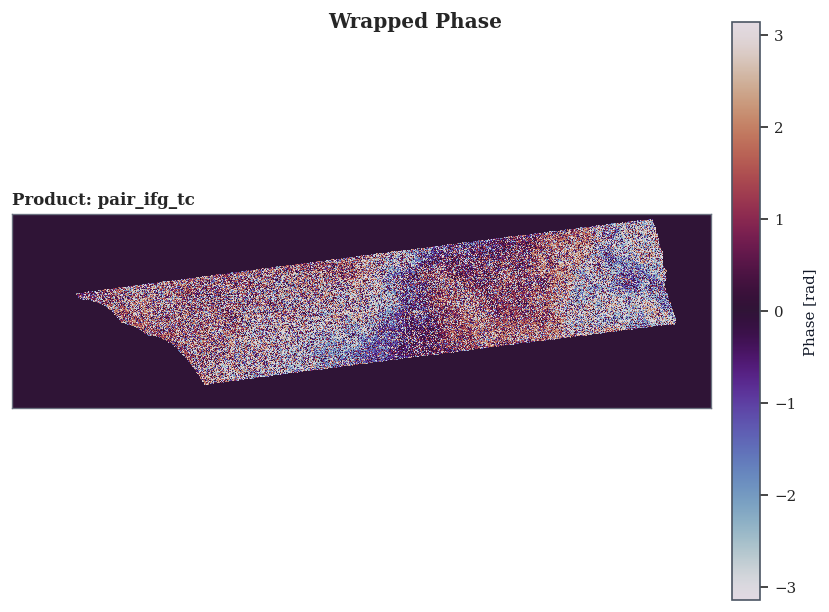

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 4.9), constrained_layout=True)
fig.suptitle("Wrapped Phase", fontsize=12, fontweight="semibold", y=1.01)

if phase_i and phase_q:
    phase_data = wrapped_phase(phase_i, phase_q)
    im = ax.imshow(phase_data, cmap="twilight", vmin=-np.pi, vmax=np.pi, interpolation="nearest")
    ax.set_title(f"Product: {phase_product.stem}", loc="left", fontsize=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Phase [rad]", fontsize=9)
    apply_map_format(ax)
else:
    mark_empty(ax, "Wrapped phase bands not available")

plt.show()


### Coherence

Coherence is separated into its own panel to make spatial quality variations easier to assess. A monotonic sequential colormap is used because coherence has a natural ordered interpretation from low to high quality.


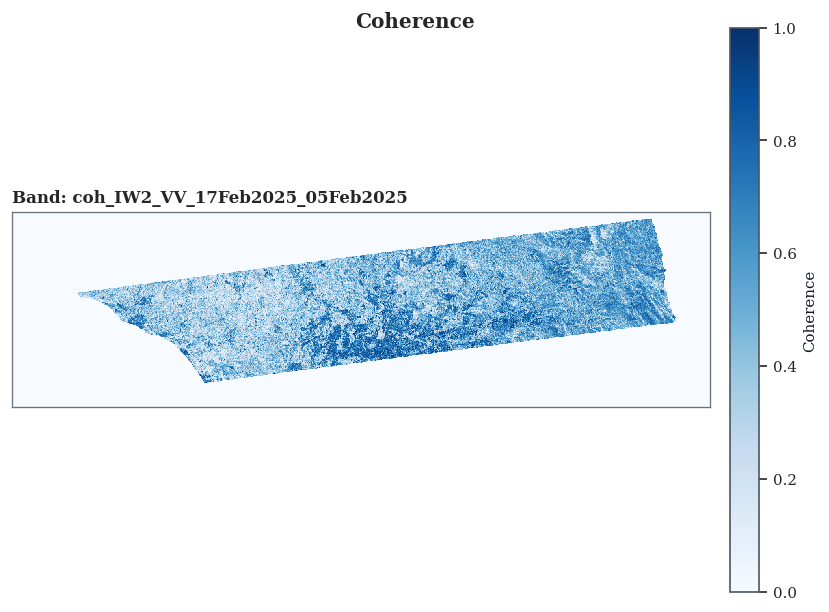

In [13]:
fig, ax = plt.subplots(figsize=(6.8, 4.9), constrained_layout=True)
fig.suptitle("Coherence", fontsize=12, fontweight="semibold", y=1.01)

if coherence_data is not None:
    im = ax.imshow(coherence_data, cmap="Blues", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_title(f"Band: {coherence_band.stem}", loc="left", fontsize=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Coherence", fontsize=9)
    apply_map_format(ax)
else:
    mark_empty(ax, "Coherence band not available")

plt.show()


### Terrain Support Raster

This panel highlights the auxiliary terrain-support layer used to contextualize the interferometric products, preferring local incidence angle when available and otherwise falling back to elevation. The purpose is explanatory rather than diagnostic: it helps relate phase and coherence structure to terrain geometry.


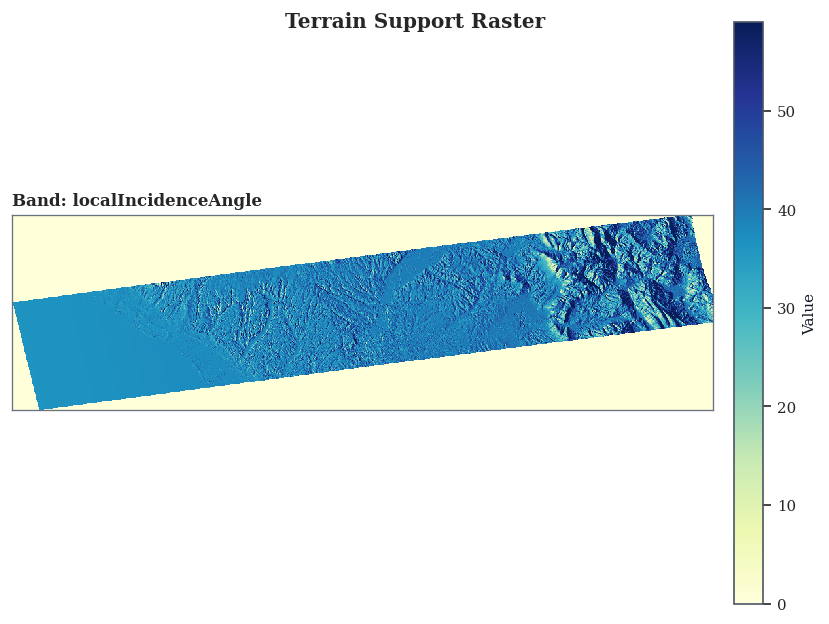

In [14]:
fig, ax = plt.subplots(figsize=(6.8, 5.0), constrained_layout=True)
fig.suptitle("Terrain Support Raster", fontsize=12, fontweight="semibold", y=1.01)

if support_data is not None:
    vmin, vmax = robust_limits(support_data)
    im = ax.imshow(support_data, cmap="YlGnBu", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(f"Band: {support_band.stem}", loc="left", fontsize=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Value", fontsize=9)
    apply_map_format(ax)
else:
    mark_empty(ax, "Terrain support raster not available")

plt.show()


### Coherence Histogram

The distribution view complements the spatial coherence map by showing central tendency, spread, and percentile range in a compact statistical graphic. This is especially useful when comparing runs, because the table and the histogram together reveal both average behavior and tail behavior.


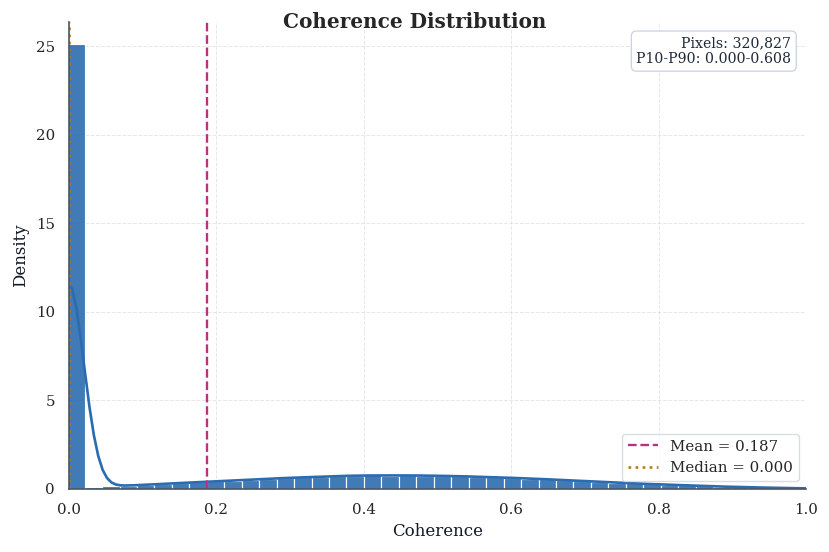

In [15]:
fig, ax = plt.subplots(figsize=(6.8, 4.4), constrained_layout=True)
fig.suptitle("Coherence Distribution", fontsize=12, fontweight="semibold", y=1.01)

if coherence_data is not None:
    valid = coherence_data[np.isfinite(coherence_data)].ravel()
    sns.histplot(
        x=valid,
        bins=50,
        kde=True,
        stat="density",
        color=IEEE_COLORS["blue"],
        edgecolor="white",
        alpha=0.9,
        line_kws={"linewidth": 1.6, "color": IEEE_COLORS["navy"]},
        ax=ax,
    )
    mean_val = float(np.nanmean(valid))
    median_val = float(np.nanmedian(valid))
    p10, p90 = np.nanpercentile(valid, [10, 90])
    ax.axvline(mean_val, color=IEEE_COLORS["crimson"], linestyle="--", linewidth=1.4, label=f"Mean = {mean_val:.3f}")
    ax.axvline(median_val, color=IEEE_COLORS["gold"], linestyle=":", linewidth=1.6, label=f"Median = {median_val:.3f}")
    ax.set_xlabel("Coherence")
    ax.set_ylabel("Density")
    ax.set_xlim(0.0, 1.0)
    ax.legend(facecolor="white", edgecolor="#cbd5e1")
    ax.text(
        0.98,
        0.97,
        f"Pixels: {valid.size:,}\nP10-P90: {p10:.3f}-{p90:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        color="#1f2937",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cbd5e1"},
    )
    sns.despine(ax=ax)
else:
    mark_empty(ax, "No coherence histogram available")

plt.show()
